# 01 - EDA: Global biofuels consumption

Country-year panel 2000-2024, source: [Our World in Data - Global
Energy dataset](https://github.com/owid/energy-data), which
consolidates data from the Energy Institute (Statistical Review of
World Energy), Ember, the Maddison Project (GDP), and population
estimates. "Biofuels" here is biodiesel and ethanol combined, as
reported by the source.

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
from src.data import load_clean_panel
from src.features import build_features

pd.set_option("display.max_columns", None)

df_raw = load_clean_panel()
print(f"Rows: {len(df_raw)}, countries: {df_raw['country'].nunique()}, "
      f"years: {df_raw['year'].min()}-{df_raw['year'].max()}")
df_raw.head()

Rows: 2608, countries: 108, years: 2000-2024


,country,year,iso_code,population,gdp,biofuel_cons_per_capita,biofuel_consumption,biofuel_electricity,biofuel_share_energy,electricity_generation,energy_per_capita,oil_consumption,renewables_share_energy
0,Algeria,2000,DZA,30903894.0,2.085542e+11,0.0,0.0,0.0,0.0,25.40,9705.756,103.132,0.050
1,Algeria,2001,DZA,31331226.0,2.234203e+11,0.0,0.0,0.0,0.0,26.62,9920.229,106.775,0.061
2,Algeria,2002,DZA,31750832.0,2.453609e+11,0.0,0.0,0.0,0.0,27.65,10139.907,118.397,0.049
3,Algeria,2003,DZA,32175813.0,2.735686e+11,0.0,0.0,0.0,0.0,29.57,10471.285,123.174,0.214
4,Algeria,2004,DZA,32628286.0,2.967736e+11,0.0,0.0,0.0,0.0,31.25,10720.079,128.747,0.194


## Data quality

In [2]:
print("Duplicates (country, year):", df_raw.duplicated(subset=["country", "year"]).sum())
print("\nNulls per column:")
print(df_raw.isna().sum())

Duplicates (country, year): 0

Nulls per column:
country                      0
year                         0
iso_code                     0
population                   1
gdp                        335
biofuel_cons_per_capita      1
biofuel_consumption          0
biofuel_electricity         29
biofuel_share_energy       633
electricity_generation      27
energy_per_capita           41
oil_consumption            633
renewables_share_energy    633
dtype: int64


`gdp` has nulls (the Maddison source doesn't cover every
country/year). Those rows are not dropped: the modeling pipeline
imputes by median. The rest of the key columns (population, biofuels
consumption) are complete because we already filtered to rows with a
non-null `biofuel_consumption` when building the panel.

## Target distribution

In [3]:
print(df_raw["biofuel_consumption"].describe())
print("\nCountries with 0 consumption in some year:",
      df_raw[df_raw["biofuel_consumption"] == 0]["country"].nunique())

count    2608.000000
mean        6.725326
std        36.335506
min         0.000000
25%         0.000000
50%         0.000000
75%         1.447500
max       523.642000
Name: biofuel_consumption, dtype: float64

Countries with 0 consumption in some year: 100


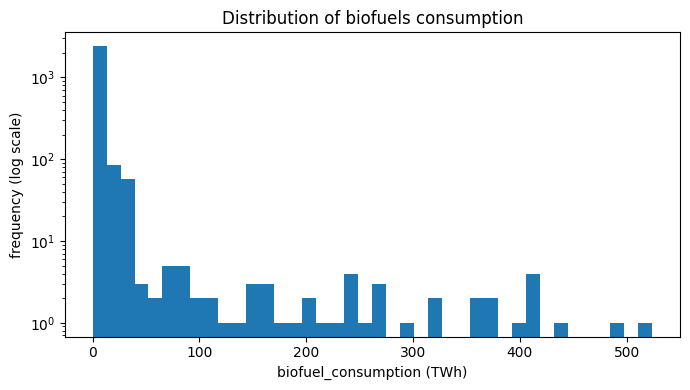

In [4]:
import matplotlib.pyplot as plt
from src.plots import plot_target_distribution

fig, ax = plt.subplots(figsize=(7, 4))
plot_target_distribution(df_raw, ax=ax)
plt.tight_layout()
plt.savefig("../reports/figures/target_distribution.png", dpi=110)
plt.show()

The distribution has a strongly long tail: most countries consume
small or zero amounts of biofuels, and a small group of countries
accounts for most of the world volume. This isn't a data-quality
issue, it's the market's real structure: a handful of large
economies with established biofuels programs (blending mandates,
domestic production) account for most of the volume, while most
countries consume little or nothing. It's the reason the project's
business metric (WMAE) weights the error in large countries more
heavily.

## Country ranking (latest available year)

In [5]:
latest_year = df_raw["year"].max()
ranking = (
    df_raw[df_raw["year"] == latest_year]
    .sort_values("biofuel_consumption", ascending=False)
    [["country", "biofuel_consumption", "biofuel_share_energy"]]
    .reset_index(drop=True)
)
ranking.index += 1
ranking.head(15)

,country,biofuel_consumption,biofuel_share_energy
1,United States,523.642,1.987
2,Brazil,269.880,7.054
3,Indonesia,120.655,4.034
4,India,47.630,0.422
5,China,37.228,0.077
6,France,34.019,1.371
7,Canada,32.977,0.863
8,Germany,30.576,0.968
9,United Kingdom,27.702,1.445
10,Thailand,22.829,1.610


## Consumption concentration (80/20 logic)

In [6]:
totals = df_raw.groupby("country")["biofuel_consumption"].sum().sort_values(ascending=False)
cum_share = (totals.cumsum() / totals.sum())
n_top80 = (cum_share <= 0.80).sum() + 1
print(f"{n_top80} countries account for ~80% of cumulative consumption 2000-{latest_year} "
      f"(out of {len(totals)} countries with data).")
cum_share.head(n_top80)

7 countries account for ~80% of cumulative consumption 2000-2024 (out of 108 countries with data).


country
United States    0.402993
Brazil           0.641905
Indonesia        0.680788
Germany          0.719497
France           0.751811
China            0.781975
Canada           0.804148
Name: biofuel_consumption, dtype: float64

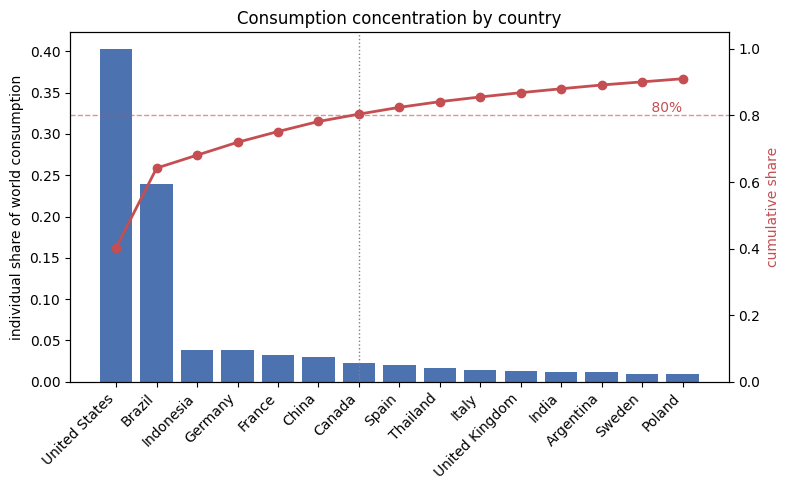

In [7]:
from src.plots import plot_cumulative_concentration

fig, ax = plt.subplots(figsize=(8, 5))
plot_cumulative_concentration(totals, cum_share, n_top80, top_n=15, ax=ax)
plt.tight_layout()
plt.savefig("../reports/figures/consumption_concentration.png", dpi=110)
plt.show()

## Derived features and correlation with macro variables

In [8]:
df_feat = build_features(df_raw)
print(df_feat.shape)
corr_cols = ["biofuel_consumption", "gdp_per_capita", "energy_per_capita",
             "oil_consumption", "renewables_share_energy"]
corr_matrix = df_feat[corr_cols].corr()
corr_matrix

(2596, 19)


,biofuel_consumption,gdp_per_capita,energy_per_capita,oil_consumption,renewables_share_energy
biofuel_consumption,1.000000,0.109950,0.048714,0.661433,0.099824
gdp_per_capita,0.109950,1.000000,0.805394,0.093512,0.126452
energy_per_capita,0.048714,0.805394,1.000000,0.076385,0.102712
oil_consumption,0.661433,0.093512,0.076385,1.000000,-0.084469
renewables_share_energy,0.099824,0.126452,0.102712,-0.084469,1.000000


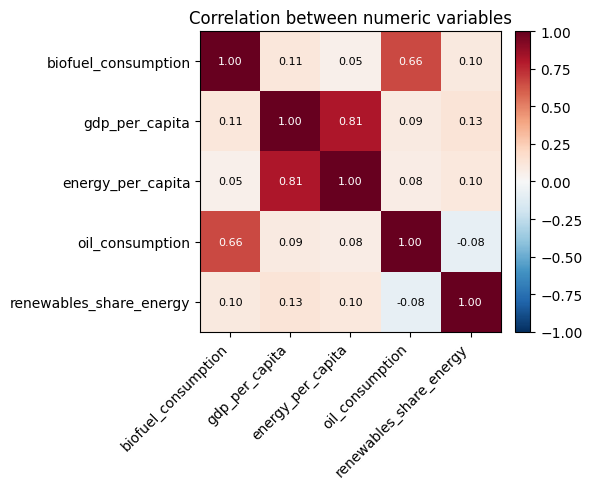

In [9]:
from src.plots import plot_correlation_heatmap

fig, ax = plt.subplots(figsize=(6, 5))
plot_correlation_heatmap(corr_matrix, ax=ax)
plt.tight_layout()
plt.savefig("../reports/figures/correlation_heatmap.png", dpi=110)
plt.show()

## EDA conclusions

- Real panel: 2,596 rows, ~107 countries, 2000-2024, no duplicates.
- `gdp` is the only column with relevant nulls, imputed by median in
  the modeling pipeline.
- The target is strongly concentrated: 5 countries account for ~80%
  of cumulative world consumption in the training period (the US,
  Brazil, Germany, France, China). This justifies the WMAE metric.
- `biofuel_consumption` correlates strongly with `oil_consumption`
  (0.66): that makes sense, biofuels consumption in absolute volume
  closely tracks the size of a country's liquid-fuels mix, not its
  wealth per capita (`gdp_per_capita` correlates only 0.11, and
  `energy_per_capita` barely at all, 0.05, because those are
  per-person measures while the target is an absolute volume
  dominated by country size). This is a useful signal for modeling:
  the size of a country's energy market matters more than its
  development level.
- `gdp_per_capita` and `energy_per_capita` correlate strongly with
  each other (0.81), as expected (wealthier countries consume more
  energy per person). Worth keeping in mind for models sensitive to
  multicollinearity between numeric features (Ridge); tree-based
  models aren't affected by it.